### Dates and Times in Python

In [2]:
from datetime import datetime
datetime.now()

datetime.datetime(2026, 8, 11, 2, 40, 8, 180828)

In [3]:
date = datetime(year = 2021, month = 3, day = 27)

In [4]:
date

datetime.datetime(2021, 3, 27, 0, 0)

In [5]:
type(date)

datetime.datetime

In [6]:
date.strftime('%B')

'March'

In [7]:
from dateutil import parser

In [8]:
date = parser.parse('5th of May, 2026')
date

datetime.datetime(2026, 5, 5, 0, 0)

In [9]:
type(date)

datetime.datetime

In [10]:
from datetime import datetime
datetime.now()

datetime.datetime(2026, 8, 11, 2, 40, 10, 278281)

In [11]:
date = datetime(year = 2020, month = 5, day = 17)
type(date)

datetime.datetime

#### Or, using the dateutil module, you can parse dates from a variety of string formats:

In [12]:
from dateutil import parser
date = parser.parse('4th of July, 2018')
date

datetime.datetime(2018, 7, 4, 0, 0)

In [13]:
date.strftime('%B')

'July'

### Typed Arrays of Times: NumPy's datetime64

In [14]:
import numpy as np

In [15]:
date = np.array('2017-08-29', dtype = np.datetime64)

In [16]:
type(date)

numpy.ndarray

In [17]:
date + np.arange(12)

array(['2017-08-29', '2017-08-30', '2017-08-31', '2017-09-01',
       '2017-09-02', '2017-09-03', '2017-09-04', '2017-09-05',
       '2017-09-06', '2017-09-07', '2017-09-08', '2017-09-09'],
      dtype='datetime64[D]')

In [18]:
np.datetime64('2017-08-29') 

np.datetime64('2017-08-29')

In [19]:
np.datetime64('2017-08-29 23:59:00') 

np.datetime64('2017-08-29T23:59:00')

In [20]:
# a minute-based datetime
np.datetime64('2021-07-04 12:00')

np.datetime64('2021-07-04T12:00')

In [21]:
# forcing a nanosecond-based time
np.datetime64('2021-07-04 12:59:59.50', 'ns')

np.datetime64('2021-07-04T12:59:59.500000000')

### Dates and Times in Pandas: The Best of Both Worlds

In [22]:
import pandas as pd

In [23]:
date = pd.to_datetime('4th of July, 2018')

In [24]:
date

Timestamp('2018-07-04 00:00:00')

In [25]:
date.strftime('%B')

'July'

In [26]:
# Additionally, we can do NumPy-style vectorized operations directly on this same object:
date

Timestamp('2018-07-04 00:00:00')

In [27]:
date + pd.to_timedelta(np.arange(12), 'h')

DatetimeIndex(['2018-07-04 00:00:00', '2018-07-04 01:00:00',
               '2018-07-04 02:00:00', '2018-07-04 03:00:00',
               '2018-07-04 04:00:00', '2018-07-04 05:00:00',
               '2018-07-04 06:00:00', '2018-07-04 07:00:00',
               '2018-07-04 08:00:00', '2018-07-04 09:00:00',
               '2018-07-04 10:00:00', '2018-07-04 11:00:00'],
              dtype='datetime64[us]', freq=None)

### Pandas Time Series: Indexing by Time

In [28]:
# Indexing timestamps
index = pd.DatetimeIndex(['2017-08-29', '2017-08-30', '2018-08-31', '2018-09-01'])

data  = pd.Series([0, 1, 2, 3], index = index)
data

2017-08-29    0
2017-08-30    1
2018-08-31    2
2018-09-01    3
dtype: int64

In [29]:
data['2018']

2018-08-31    2
2018-09-01    3
dtype: int64

In [30]:
data['2020-07-04':'2021-07-04']

Series([], dtype: int64)

In [31]:
# special date-only indexing operations, such as passing a year to obtain a slice of all data from that year
data['2021']

KeyError: '2021'

### Pandas Time Series Data Structures

In [ ]:
dates = pd.to_datetime([datetime(2021, 7, 3), '4th of July, 2021',
                       '2021-Jul-6', '07-07-2021', '20210708'])
dates

DatetimeIndex(['2021-07-03', '2021-07-04', '2021-07-06', '2021-07-07',
               '2021-07-08'],
              dtype='datetime64[us]', freq=None)

In [ ]:
dates.to_period('Y')

PeriodIndex(['2021', '2021', '2021', '2021', '2021'], dtype='period[Y-DEC]')

In [ ]:
dates

DatetimeIndex(['2021-07-03', '2021-07-04', '2021-07-06', '2021-07-07',
               '2021-07-08'],
              dtype='datetime64[us]', freq=None)

In [ ]:
dates[0]

Timestamp('2021-07-03 00:00:00')

In [ ]:
dates - dates[0]

TimedeltaIndex(['0 days', '1 days', '3 days', '4 days', '5 days'], dtype='timedelta64[us]', freq=None)

### Regular Sequences: pd.date_range

##### pd.date_range for timestamps, pd.period_range for periods, and pd.timedelta_range for time deltas. We've seen that Python's range and NumPy's np.arange take a start point, end point, and optional step size and return a sequence. Similarly, pd.date_range accepts a start date, an end date, and an optional frequency code to create a regular sequence of dates:

In [ ]:
pd.date_range('2015-07-03', '2015-07-10')

DatetimeIndex(['2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06',
               '2015-07-07', '2015-07-08', '2015-07-09', '2015-07-10'],
              dtype='datetime64[us]', freq='D')

In [ ]:
#  a start point and a number of periods
pd.date_range('2015-07-03', periods=8)

DatetimeIndex(['2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06',
               '2015-07-07', '2015-07-08', '2015-07-09', '2015-07-10'],
              dtype='datetime64[us]', freq='D')

In [ ]:
#altering the freq argument, which defaults to D
pd.date_range('2015-07-03', periods=8, freq='h')

DatetimeIndex(['2015-07-03 00:00:00', '2015-07-03 01:00:00',
               '2015-07-03 02:00:00', '2015-07-03 03:00:00',
               '2015-07-03 04:00:00', '2015-07-03 05:00:00',
               '2015-07-03 06:00:00', '2015-07-03 07:00:00'],
              dtype='datetime64[us]', freq='h')

In [ ]:
pd.period_range('2015-07', periods=8, freq='M')

PeriodIndex(['2015-07', '2015-08', '2015-09', '2015-10', '2015-11', '2015-12',
             '2016-01', '2016-02'],
            dtype='period[M]')

In [ ]:
pd.timedelta_range(0, periods=6, freq='h')

TimedeltaIndex(['0 days 00:00:00', '0 days 01:00:00', '0 days 02:00:00',
                '0 days 03:00:00', '0 days 04:00:00', '0 days 05:00:00'],
               dtype='timedelta64[ns]', freq='h')

### Frequencies and offset

In [ ]:
from pandas.tseries.offsets import BDay
pd.date_range('2015-07-01', periods=6, freq=BDay())

DatetimeIndex(['2015-07-01', '2015-07-02', '2015-07-03', '2015-07-06',
               '2015-07-07', '2015-07-08'],
              dtype='datetime64[us]', freq='B')

### Resampling, Shifting, and Windowing

In [15]:
import pandas as pd

In [3]:
import yfinance as yf

sp500 = yf.download('^GSPC', start='2018-01-01', end='2022-01-01')
sp500.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2018-01-02,2695.810059,2695.889893,2682.360107,2683.729980,3397430000
2018-01-03,2713.060059,2714.370117,2697.770020,2697.850098,3544030000
2018-01-04,2723.989990,2729.290039,2719.070068,2719.310059,3697340000
2018-01-05,2743.149902,2743.449951,2727.919922,2731.330078,3239280000
2018-01-08,2747.709961,2748.510010,2737.600098,2742.669922,3246160000


In [4]:
sp500 = sp500['Close']

In [1]:
import sys
print(sys.executable)

c:\Users\Nicole Kasiva\Documents\Python-data-analysis\env\Scripts\python.exe


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='Date'>

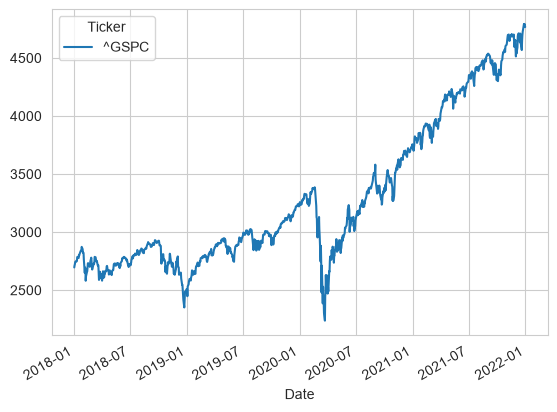

In [7]:
sns.set_style('whitegrid')
sp500.plot()

### Resampling and converting frequencies 

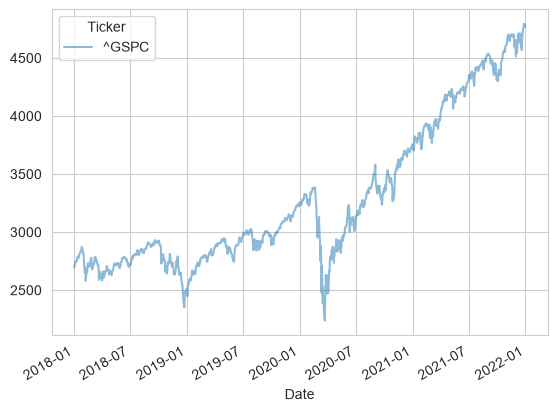

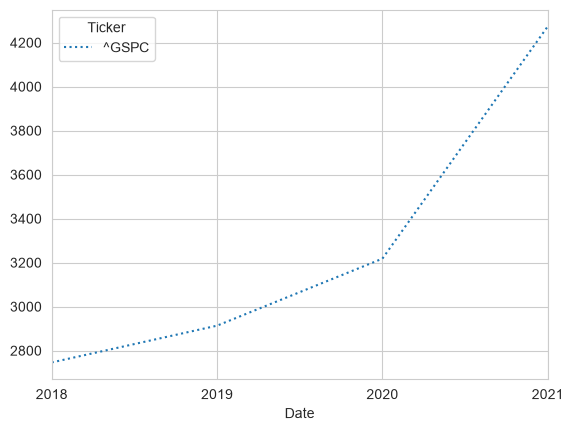

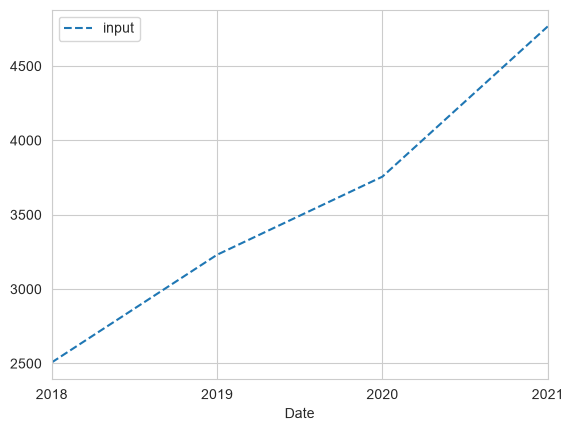

In [8]:
sp500.plot(alpha=0.5, style='-')

sp500.resample('YE').mean().plot(style=':')
sp500.asfreq('YE').plot(style='--')

plt.legend(['input', 'resample', 'asfreq'], loc='upper left')
plt.show()

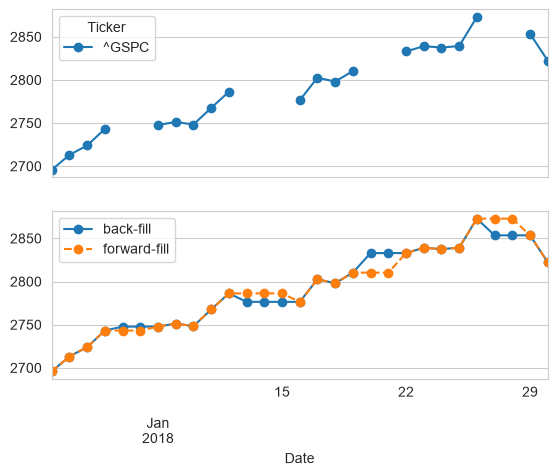

In [9]:
fig, ax = plt.subplots(2, sharex=True)
data = sp500.iloc[:20]

data.asfreq('D').plot(ax=ax[0], marker='o')

data.asfreq('D', method='bfill').plot(ax=ax[1], style='-o')
data.asfreq('D', method='ffill').plot(ax=ax[1], style='--o')
ax[1].legend(["back-fill", "forward-fill"])

### Time shifts

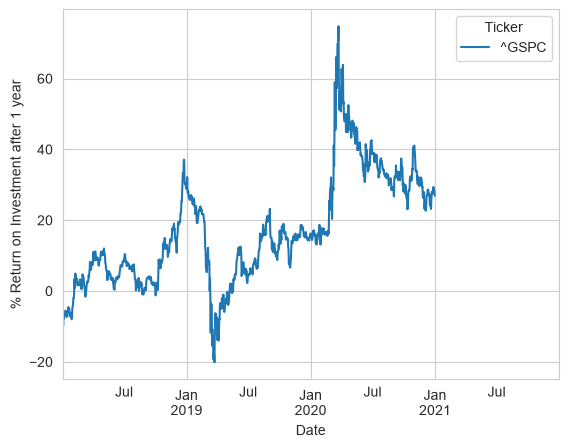

In [10]:
sp500 = sp500.asfreq('D', method='pad')

ROI = 100 * (sp500.shift(-365) - sp500) / sp500
ROI.plot()
plt.ylabel('% Return on Investment after 1 year');

In [11]:
#url = ('https://raw.githubusercontent.com/jakevdp/'
      # 'bicycle-data/main/FremontBridge.csv')
 #!curl -O {url}

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0           00:12              0
  0  4.47M   0  16384   0      0   1192      0 1:05:39   00:13 1:05:26  15090
  0  4.47M   0  16384   0      0   1111      0 1:10:26   00:14 1:10:12   7833
  0  4.47M   0  16384   0      0   1040      0 1:15:14   00:15 1:14:59   5293
  0  4.47M   0  16384   0      0    973      0 1:20:25   00:16 1:20:09   3918
  4  4.47M   4 192.0k   0      0  10948      0   07:08   00:17   06:51  37057
 59  4.47M  59  2.67M   0      0 139.7k      0   00:32   00:19   00:13 462.8k
 90  4.47M  90  4.06M   0      0 193.4k      0   00:23   00:21   00:02 613.5k
 90  4.47M  90  4.06M   0      0 184.1k      0   00:24   00:22   00:02 606.2k
 90  4.47M  90  4.06M   0      0 175.3k      0   00:26   00:23   00:03 601.0k
100  4.47M 100  4.47M   0      0 189.5k      0   00:24   00:24 

In [17]:
data = pd.read_csv(url, index_col='Date', parse_dates=True)
data.head()

C:\Users\Nicole Kasiva\AppData\Local\Temp\ipykernel_6308\692871321.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(url, index_col='Date', parse_dates=True)


,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
Date,,,
2019-11-01 00:00:00,12.0,7.0,5.0
2019-11-01 01:00:00,7.0,0.0,7.0
2019-11-01 02:00:00,1.0,0.0,1.0
2019-11-01 03:00:00,6.0,6.0,0.0
2019-11-01 04:00:00,6.0,5.0,1.0


In [ ]:
data.columns = ['Total', 'East', 'West'] #shortening column names 

In [19]:
#summary statistics
data.dropna().describe() 

,Total,East,West
count,147255.000000,147255.000000,147255.000000
mean,110.341462,50.077763,60.263699
std,140.422051,64.634038,87.252147
min,0.000000,0.000000,0.000000
25%,14.000000,6.000000,7.000000
50%,60.000000,28.000000,30.000000
75%,145.000000,68.000000,74.000000
max,1097.000000,698.000000,850.000000


#### Visualizing the data

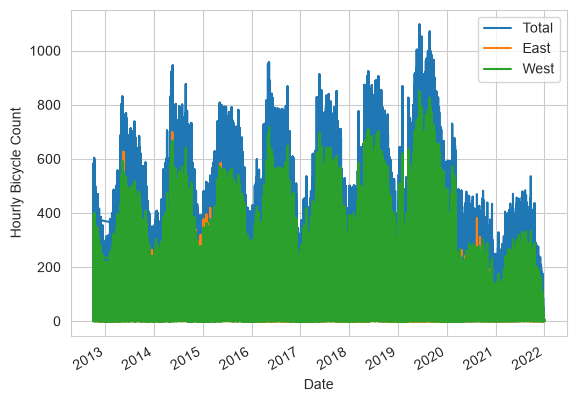

In [20]:
data.plot()
plt.ylabel('Hourly Bicycle Count');

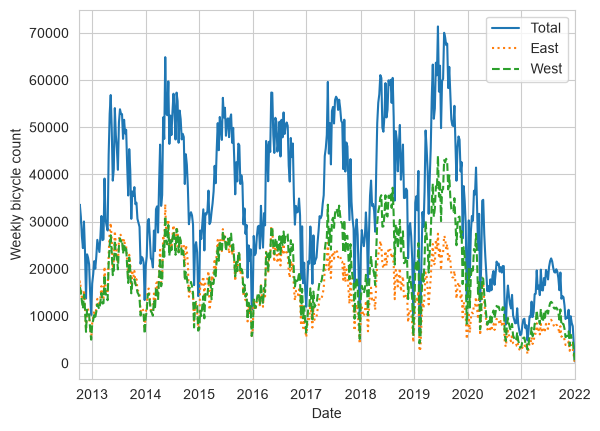

In [21]:
weekly = data.resample('W').sum()
weekly.plot(style=['-', ':', '--'])
plt.ylabel('Weekly bicycle count');

In [22]:
data.dtypes

Total    float64
East     float64
West     float64
dtype: object

In [23]:
data['Total'] = pd.to_numeric(data['Total'], errors='coerce')

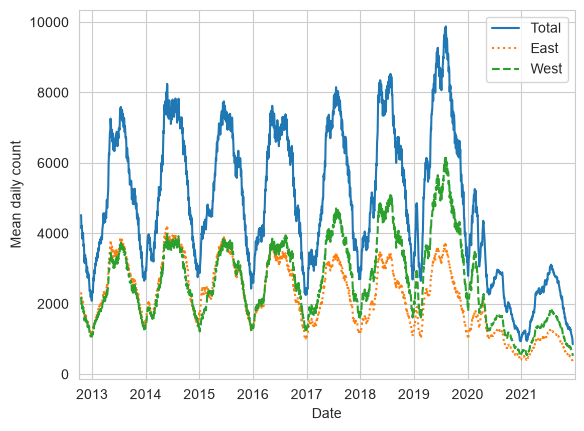

In [24]:
daily = data.select_dtypes(include='number').resample('D').sum()
rolling = daily.rolling(30, center=True).mean()
rolling.plot(style=['-', ':', '--'])
plt.ylabel('Mean daily count')
plt.show()

### Digging into the Data

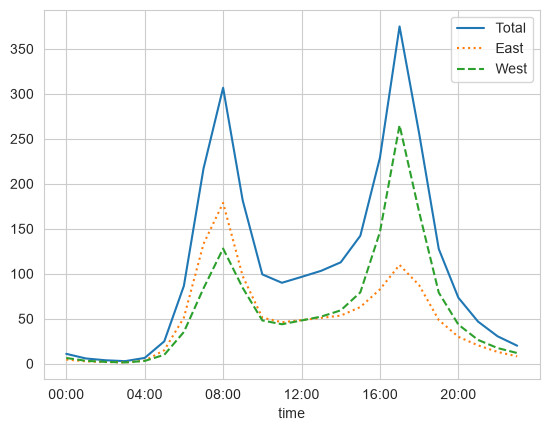

In [29]:
by_time = data.groupby(data.index.time).mean()
hourly_ticks = 4 * 60 * 60 * np.arange(6)
by_time.plot(xticks=hourly_ticks, style=['-', ':', '--']);

In [28]:
import numpy as np

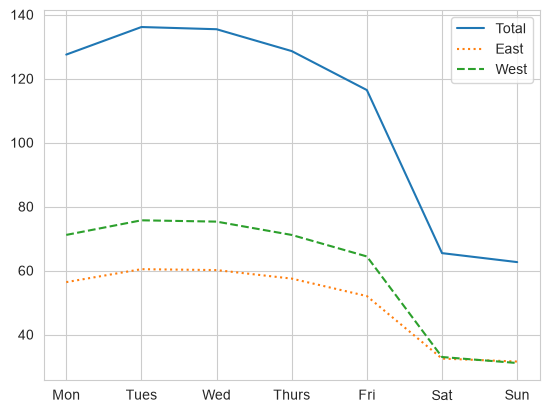

In [30]:
by_weekday = data.groupby(data.index.dayofweek).mean()
by_weekday.index = ['Mon', 'Tues', 'Wed', 'Thurs', 'Fri', 'Sat', 'Sun']
by_weekday.plot(style=['-', ':', '--']);

In [31]:
# using groupby
weekend = np.where(data.index.weekday < 5, 'Weekday', 'Weekend')
by_time = data.groupby([weekend, data.index.time]).mean()

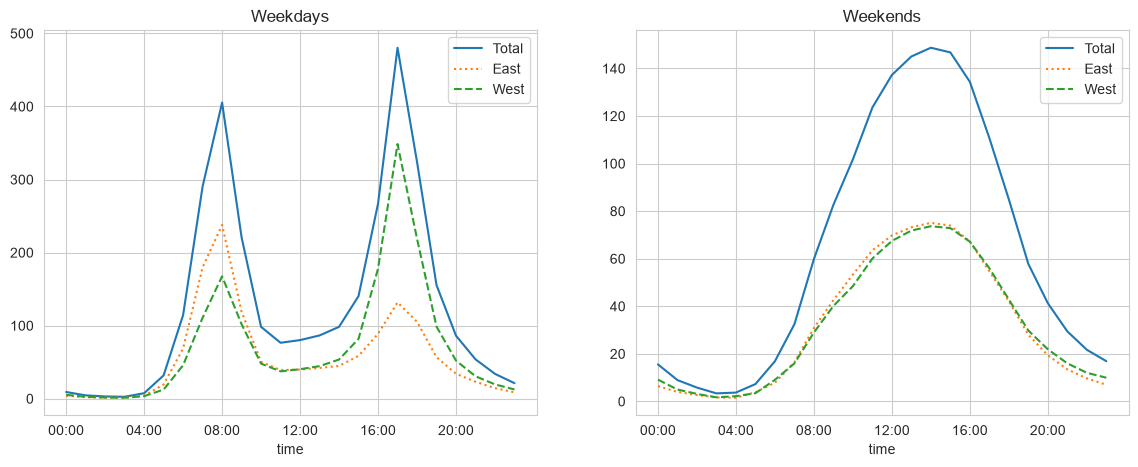

In [32]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
by_time.loc['Weekday'].plot(ax=ax[0], title='Weekdays',
                            xticks=hourly_ticks, style=['-', ':', '--'])
by_time.loc['Weekend'].plot(ax=ax[1], title='Weekends',
                            xticks=hourly_ticks, style=['-', ':', '--']);